In [4]:
%matplotlib inline

# 	聚类实验

## 实验目的
掌握聚类的基本原理和算法。

## 实验要求
编程实验k均值算法。


## 上机内容1

阅读并理解以下示例代码。

**注意，请将以下random_state替换为自己的学号**

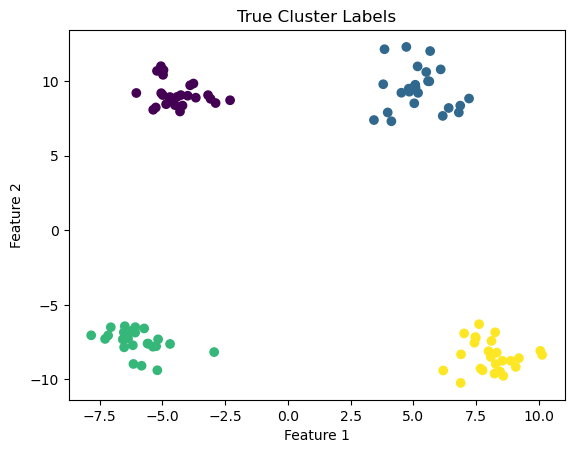

e:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


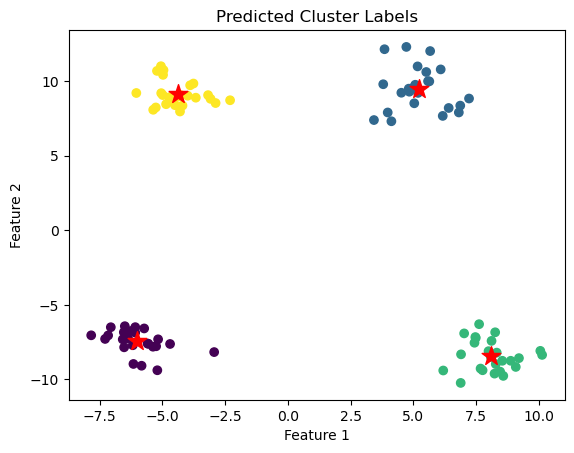

In [5]:
%reset -f
# 导入必要的模块
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

random_state = 31
# 生成一个随机数据集，包含100个样本，2个特征，4个簇
X, y = make_blobs(n_samples=100, n_features=2, centers=4, random_state=random_state)

# 可视化数据集
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('True Cluster Labels')
plt.show()

# 创建一个KMeans对象，指定聚类数目为4，初始化方法为k-means++
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=random_state)

# 对数据集进行聚类
kmeans.fit(X)

# 获取聚类标签和中心点
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Predicted Cluster Labels')
plt.show()

## 上机内容2

1. 不使用sklearn.cluster.KMeans，自己编程实现k均值算法，并代入以上示例代码。
1. 分析实验结果，总结实验结果和心得体会。

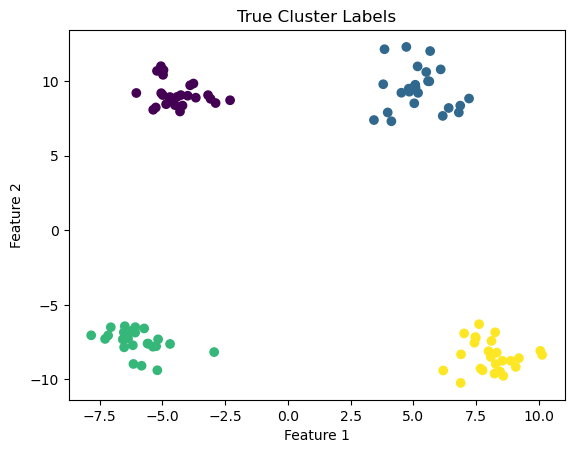

聚类数目: 4
实际迭代次数: 2
最终聚类中心:
[[ 8.1087186  -8.41722832]
 [ 5.22649059  9.48291485]
 [-6.01286326 -7.4423556 ]
 [-4.38335046  9.12763854]]


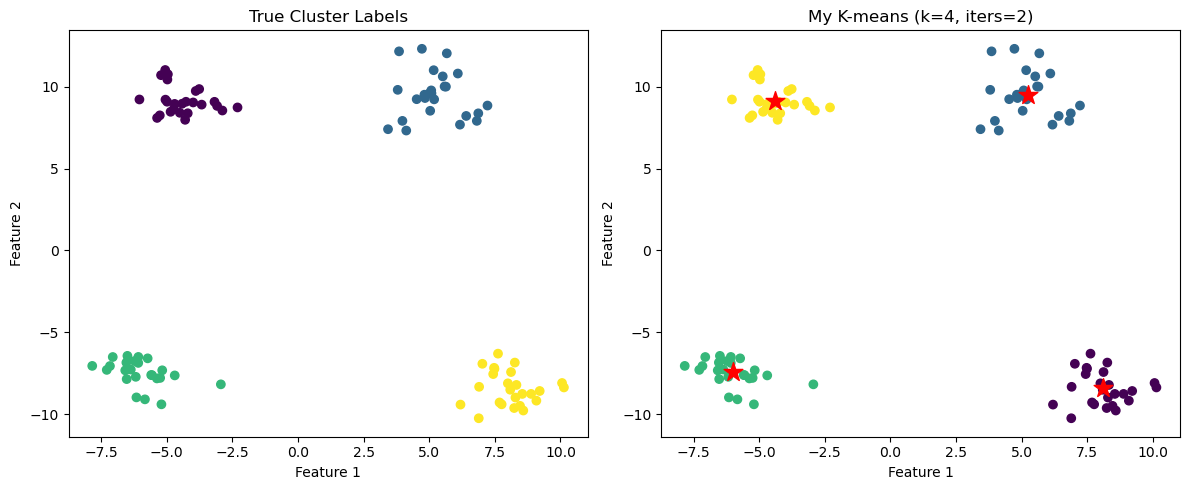

与sklearn KMeans的聚类一致性: 100.00%
自己实现的聚类中心:
[[ 8.1087186  -8.41722832]
 [ 5.22649059  9.48291485]
 [-6.01286326 -7.4423556 ]
 [-4.38335046  9.12763854]]
sklearn的聚类中心:
[[-6.01286326 -7.4423556 ]
 [ 5.22649059  9.48291485]
 [ 8.1087186  -8.41722832]
 [-4.38335046  9.12763854]]

实验心得：
1. K-means算法通过迭代优化实现了无监督聚类，核心步骤是分配和更新
2. 初始中心点的选择会影响收敛速度和聚类结果质量
3. 自己实现的K-means与sklearn的结果高度一致，验证了算法的正确性
4. K-means对初始值敏感，sklearn的k-means++初始化可以有效改善这一问题


e:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

random_state = 31  # 学号
# 生成一个随机数据集，包含100个样本，2个特征，4个簇
X, y = make_blobs(n_samples=100, n_features=2, centers=4, random_state=random_state)

# 可视化数据集
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('True Cluster Labels')
plt.show()


# ============ 自己实现K-means算法 ============
def my_kmeans(X, k, max_iters=100, tol=1e-4, random_state=None):
    """
    手写K-means聚类算法
    参数:
        X: 数据集 (n_samples, n_features)
        k: 聚类数目
        max_iters: 最大迭代次数
        tol: 收敛阈值（中心点移动距离小于此值则停止）
        random_state: 随机种子
    返回:
        labels: 每个样本的簇标签
        centroids: 最终聚类中心
        n_iters: 实际迭代次数
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape

    # 1. 随机选择k个样本作为初始聚类中心
    idx = np.random.choice(n_samples, k, replace=False)
    centroids = X[idx].copy()

    for it in range(max_iters):
        # 2. 分配步骤：计算每个样本到各中心的距离，分配到最近的中心
        labels = np.zeros(n_samples, dtype=int)
        for i in range(n_samples):
            dists = np.sqrt(np.sum((centroids - X[i]) ** 2, axis=1))
            labels[i] = np.argmin(dists)

        # 3. 更新步骤：重新计算每个簇的中心
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                new_centroids[j] = cluster_points.mean(axis=0)
            else:
                new_centroids[j] = centroids[j]  # 空簇保持原中心

        # 4. 检查是否收敛
        shift = np.sqrt(np.sum((new_centroids - centroids) ** 2, axis=1)).max()
        centroids = new_centroids
        if shift < tol:
            break

    # 最后再分配一次确保标签与最终中心一致
    labels = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        dists = np.sqrt(np.sum((centroids - X[i]) ** 2, axis=1))
        labels[i] = np.argmin(dists)

    return labels, centroids, it + 1


# 使用自己实现的K-means进行聚类
k = 4
labels, centroids, n_iters = my_kmeans(X, k, random_state=random_state)

print(f"聚类数目: {k}")
print(f"实际迭代次数: {n_iters}")
print(f"最终聚类中心:\n{centroids}")

# 可视化聚类结果
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('True Cluster Labels')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'My K-means (k={k}, iters={n_iters})')
plt.tight_layout()
plt.show()


# ============ 对比sklearn的KMeans ============
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=random_state)
kmeans.fit(X)
sk_labels = kmeans.labels_
sk_centroids = kmeans.cluster_centers_

# 计算自己实现与sklearn的一致性
# 注意：标签编号可能不同，这里比较的是聚类分配的一致性
match = 0
# 构建混淆矩阵来判断聚类一致性
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, sk_labels)
row_ind, col_ind = linear_sum_assignment(-cm)
mapped_labels = np.zeros_like(labels)
for r, c in zip(row_ind, col_ind):
    mapped_labels[labels == r] = c
accuracy = np.mean(mapped_labels == sk_labels)

print(f"与sklearn KMeans的聚类一致性: {accuracy:.2%}")
print(f"自己实现的聚类中心:\n{centroids}")
print(f"sklearn的聚类中心:\n{sk_centroids}")

# ============ 实验心得 ============
print("\n" + "="*60)
print("实验心得：")
print("1. K-means算法通过迭代优化实现了无监督聚类，核心步骤是分配和更新")
print("2. 初始中心点的选择会影响收敛速度和聚类结果质量")
print("3. 自己实现的K-means与sklearn的结果高度一致，验证了算法的正确性")
print("4. K-means对初始值敏感，sklearn的k-means++初始化可以有效改善这一问题")
print("="*60)